DSCI 552 Homework 5

Name: Brynn Dafoe GitHub Username: brynndafoe02 USD ID: 3109-6692-10

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import RocCurveDisplay, roc_auc_score, accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn import datasets
from sklearn.feature_selection import RFE
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree

from skmultilearn.problem_transform import LabelPowerset

# from imblearn.under_sampling import RandomUnderSampler

# from itertools import combinations
# import seaborn as sns

# import statsmodels.api as sm
# import statsmodels.formula.api as smf

# from pathlib import Path
# import re

Question 1 -> diagnosis.data + diagnosis.names
Question 1.b
- Build a decision tree on the whole data set and plot it
- - This data set is a multi-label data set
  - Sk-Learn seems to support building multi-label decision trees
  - Alternatively, you can use the label powerset method to convert it to a multiclass data set
  - Also, you can use the binary relevance method and build one decision tree for each label
  - It seems that the label powerset approach is more relevent here

In [64]:
# -- Attribute lines:
# For example, '35,9 no no yes yes yes yes no'
# Where:
# '35,9' Temperature of patient
# 'no' Occurrence of nausea
# 'no' Lumbar pain
# 'yes' Urine pushing (continuous need for urination)
# 'yes' Micturition pains
# 'yes' Burning of urethra, itch, swelling of urethra outlet
# 'yes' decision: Inflammation of urinary bladder
# 'no' decision: Nephritis of renal pelvis origin 

# Attribute Information:

# a1 Temperature of patient { 35C-42C }
# a2 Occurrence of nausea { yes, no }
# a3 Lumbar pain { yes, no }
# a4 Urine pushing (continuous need for urination) { yes, no }
# a5 Micturition pains { yes, no }
# a6 Burning of urethra, itch, swelling of urethra outlet { yes, no }
# d1 decision: Inflammation of urinary bladder { yes, no }
# d2 decision: Nephritis of renal pelvis origin { yes, no } 

# ^^^ Inflam and Neph are being predicted on / = Y
# ^^^ T, N, LP, UP, MP, B = X

# "../data/CCPP/Folds5x2_pp.xlsx"

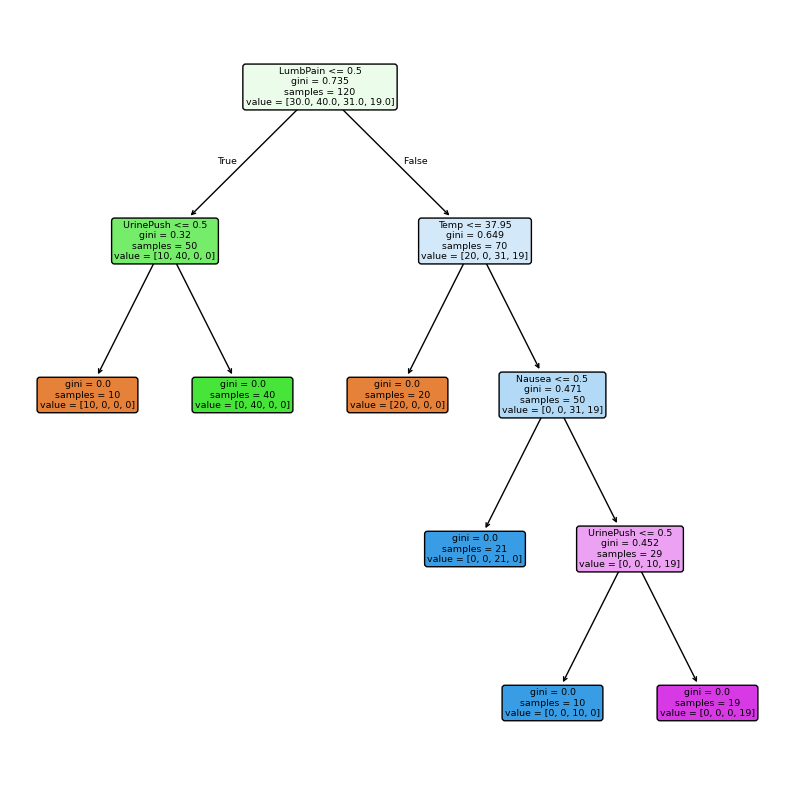

In [65]:
d_column_names = ["Temp", "Nausea", "LumbPain", "UrinePush", 
                  "MictPains", "Burning", "Inflam", "Neph"] # 8 columns

d_df = pd.read_csv("../data/diagnosis.data", header=None, names=d_column_names, decimal=',', sep=r'\s+', encoding='utf-16')

d_df = d_df.replace({"yes": 1, "no": 0})

# pd.set_option('display.max_rows', None)
# print(d_df)

d_X = d_df[["Temp", "Nausea", "LumbPain", "UrinePush", "MictPains", "Burning"]].astype(float).values
d_Y = d_df[["Inflam", "Neph"]].astype(float).values # forcing to be numbers because it was still reading as objects at first

clf = LabelPowerset(classifier=DecisionTreeClassifier(random_state=42))
clf.fit(d_X, d_Y)

plt.figure(figsize=(10, 10))
plot_tree(clf.classifier, feature_names=["Temp", "Nausea", "LumbPain", "UrinePush", "MictPains", "Burning"], filled=True, rounded=True)
plt.show()

    

Question 1.c
- Convert the decision rules into a set of IF-THEN rules
- - Using code from kdnuggets

In [66]:
def tree_to_pseudo(tree, feature_names):
    left = tree.tree_.children_left
    right = tree.tree_.children_right
    threshold = tree.tree_.threshold
    features = [feature_names[i] for i in tree.tree_.feature]
    value = tree.tree_.value

    def recurse(left, right, threshold, features, node, depth=0):
        indent = "  " * depth
        if threshold[node] != -2:
            print(indent,"if ( " + features[node] + " <= " + str(threshold[node]) + " ) {")
            if left[node] != -1:
                recurse(left, right, threshold, features, left[node], depth+1)
                print(indent,"} else {")
                if right[node] != -1:
                    recurse(left, right, threshold, features, right[node], depth+1)
                print(indent,"}")
        else:
            print(indent,"return " + str(value[node]))

    recurse(left, right, threshold, features, 0)
               

In [67]:
feature_names = ["Temp", "Nausea", "LumbPain", "UrinePush", "MictPains", "Burning"]
tree_to_pseudo(clf.classifier, feature_names)

 if ( LumbPain <= 0.5 ) {
   if ( UrinePush <= 0.5 ) {
     return [[1. 0. 0. 0.]]
   } else {
     return [[0. 1. 0. 0.]]
   }
 } else {
   if ( Temp <= 37.95000076293945 ) {
     return [[1. 0. 0. 0.]]
   } else {
     if ( Nausea <= 0.5 ) {
       return [[0. 0. 1. 0.]]
     } else {
       if ( UrinePush <= 0.5 ) {
         return [[0. 0. 1. 0.]]
       } else {
         return [[0. 0. 0. 1.]]
       }
     }
   }
 }


In [68]:
# ^^^ what the printed returns mean
print(clf.unique_combinations_)
# no labels, label 0 (Inflam), label 1 (Neph), both labels
# 1000 -> no labels -> Neither
# 0100 -> label 0 -> Inflammation
# 0010 -> label 1 -> Nephritis
# 0001 -> both labels -> Inflammation + Nephritis

{'': 0, '0': 1, '1': 2, '0,1': 3}
